In [1]:
%load_ext autoreload

In [2]:
import sys, os

dir = os.path.abspath('..')
sys.path.append(os.path.join(dir))

In [3]:
from synth_utils import Demo

language_1 = 'You want to grab the box, move towards the human and if they are left handed you want to leave the box by their left side, then go back to your original spot.'
language_2 = 'Grab the box, move towards the human. If right handed drop the box by their right side. Finally go back where you started.'

demos = [
    Demo(id='demo_1', scene=None, language=language_1, video=None),
    Demo(id='demo_2', scene=None, language=language_2, video=None)
]

In [4]:
from factory_api.api import api
from infer_utils import Inference
acts = Inference.act_from(demos, api)

  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:12<00:00,  6.23s/it]

Inference done.


The behavior involves picking up a box, moving towards a human, determining if they are left-handed, placing the box on their left side if they are, and then returning to the original spot.


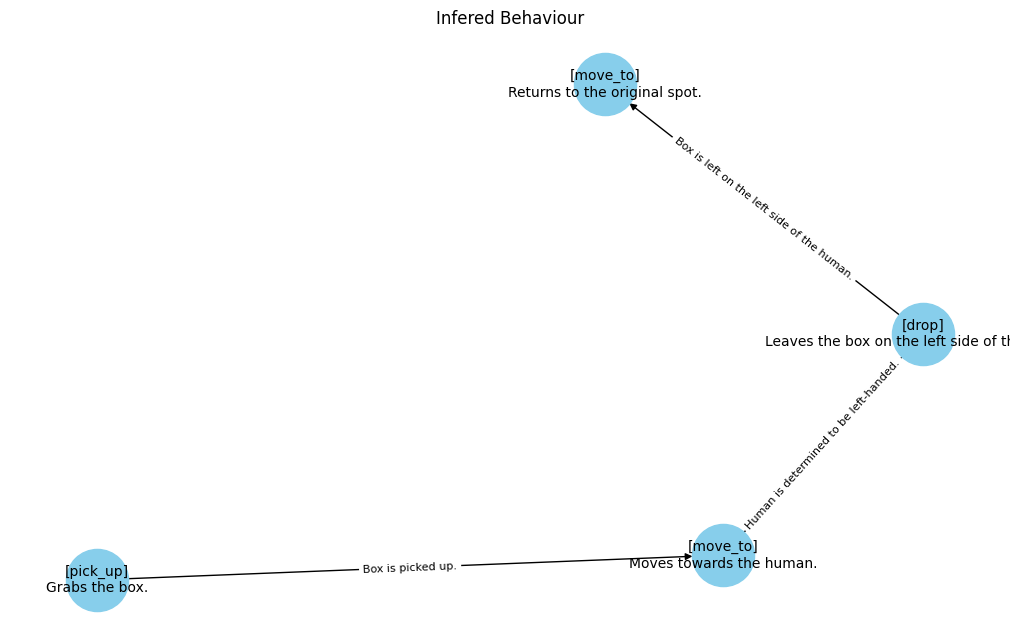

The behavior involves picking up a box, moving towards a human, determining the side based on handedness, dropping the box on that side, and then returning to the starting position.


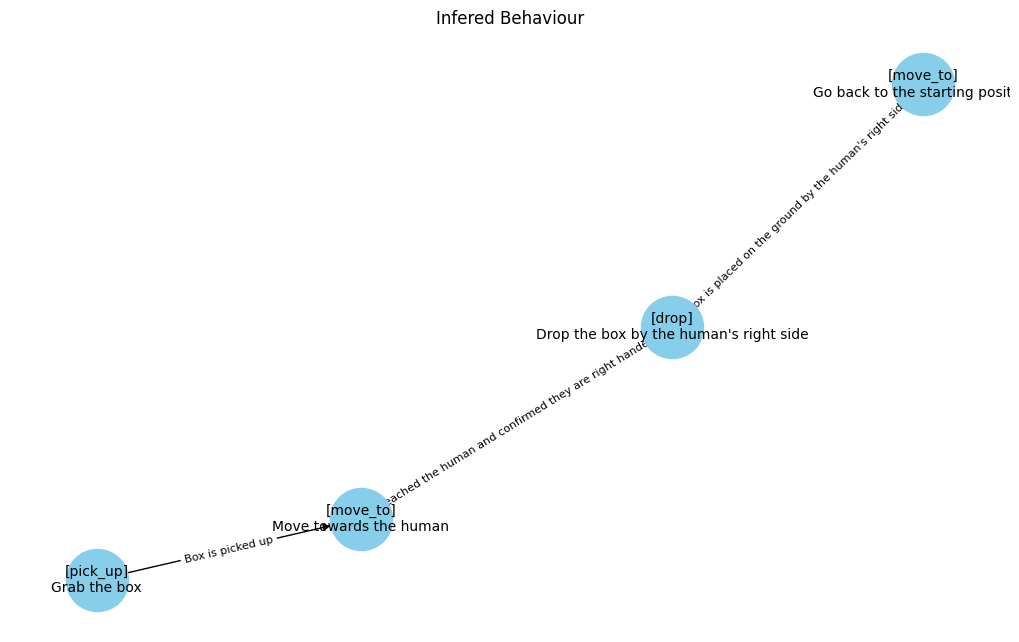

In [5]:
for a in acts:
    print(a.outline)
    a.show()

Editing done.
This behavior models a process where an object, such as a robot, picks up a box, approaches a human, determines the human's handedness, places the box on the appropriate side of the human, and finally returns to the starting position. This system is designed to adapt to the human's handedness and execute actions accordingly.


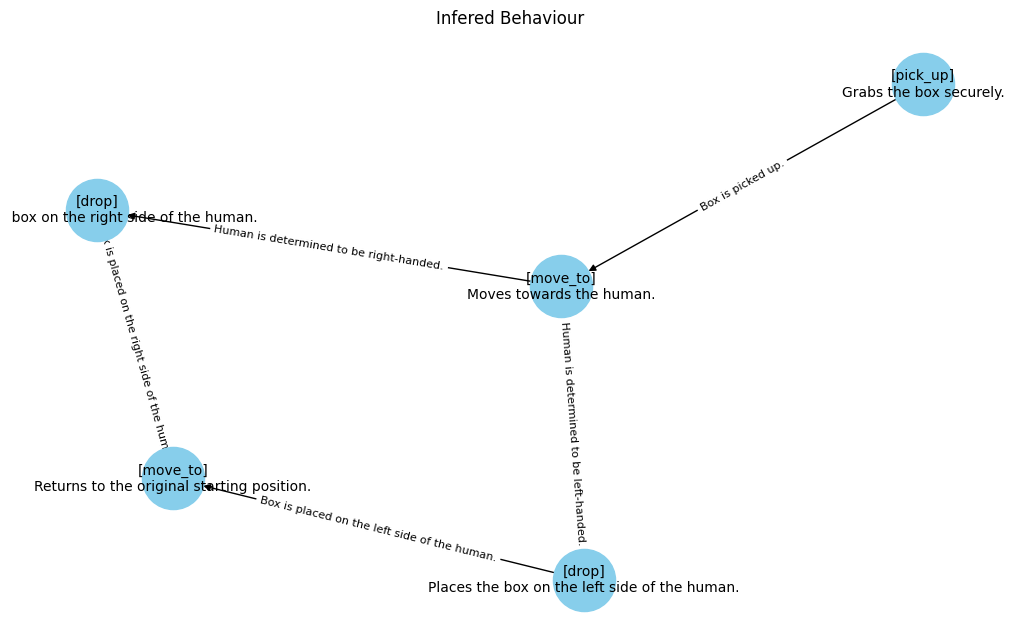

In [6]:
act = Inference.combine(acts, api)

print(act.outline)
act.show()

In [7]:
%load_ext autoreload
%autoreload 2

act.interactive_fsm()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
import json

OUT_DIR = 'exports'

os.makedirs(OUT_DIR, exist_ok=True)
for idx, a in enumerate(acts):

    id = f'act_{idx + 1}'
    data = a.to_dict(id=id, expanded=False)

    with open(f'{OUT_DIR}/{id}.json', 'w') as f:
        json.dump(data, f, indent=4)

In [9]:
# TODO: Automate act editing

In [10]:
# NOTE: Import final act
act = acts[0]

In [11]:
%load_ext autoreload
%autoreload 2

from synth_utils import Synth

synth = Synth(act, demos, api)
synth.run()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


KeyError: <API.constraints: 'constraints'>

In [ ]:
%load_ext autoreload
%autoreload 2

program = synth.to_dict()
print(json.dumps(program, indent=4))